# 10.3.1 输入位置与能控矩阵

## 学习目标与先修知识

推导二维能控矩阵（matrix）并检查不能影响的状态（state）方向。

先修：第3.2章二维状态空间（state space）与矩阵秩（rank）；第10.2章闭环极点（pole）。

## 具体问题

一个输入（input）究竟能否通过系统动态影响每个状态？单看输入矩阵B的非零位置会漏掉“先作用某一状态，再经A传到另一状态”的路径。

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

双积分模型（model） A=[[0,1],[0,0]]。分别手算 B=[0,1]ᵀ 与 B=[1,0]ᵀ 的AB。

In [2]:
A=np.array([[0.,1.],[0.,0.]]);print("B1, AB1:", [0.,1.],(A@np.array([0.,1.])).tolist());print("B2, AB2:",[1.,0.],(A@np.array([1.,0.])).tolist())

B1, AB1: [0.0, 1.0] [1.0, 0.0]
B2, AB2: [1.0, 0.0] [0.0, 0.0]


## 模型假设

二维线性系统为 $\dot x=Ax+Bu$，A和B已知且在所考察区间固定，输入u暂不受幅度限制。此节讨论给定线性系统的能控性（controllability），不讨论有限时间可达所需的输入大小。给定数值矩阵时，数值秩的容差须结合尺度；数学非零行列式（determinant）与有限精度判定是不同陈述。

## 数学解释与推导

从零初始状态出发，输入首先沿 $B$ 方向影响状态的变化率；状态间的连续耦合又让这份影响沿 $AB$ 方向传播。因此二维单输入系统的能控矩阵是
$$\mathcal C=[B\ \ AB].$$
若 $\det\mathcal C\ne0$，这两个方向张成整个二维状态空间。对 $A=\begin{bmatrix}0&1\\0&0\end{bmatrix}$，$B_1=(0,1)^\mathsf T$ 给出 $AB_1=(1,0)^\mathsf T$，行列式−1；$B_2=(1,0)^\mathsf T$ 给出 $AB_2=0$，秩只有1。后一输入不能改变第二状态。

有限输入上限下的有限时域可达集合比无约束线性能控性更窄。秩为2不意味着任意初态都能在指定短时间内用有限执行器到达目标；控制设计还要考虑所需输入和模型误差。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def controllability_2d(A, B):
    AB = [A[i][0] * B[0] + A[i][1] * B[1] for i in range(2)]
    matrix = [[B[0], AB[0]], [B[1], AB[1]]]
    determinant = matrix[0][0] * matrix[1][1] - matrix[0][1] * matrix[1][0]
    return matrix, determinant

## 对照实验

对两个输入位置画出同一批固定脉冲下的状态响应，并展示能控矩阵与行列式；用同一矩阵A隔离输入位置这一变化。

Input to second state [B,AB]= [[0.0, 1.0], [1.0, 0.0]] det= -1.0
Input to first state [B,AB]= [[1.0, 0.0], [0.0, 0.0]] det= 0.0


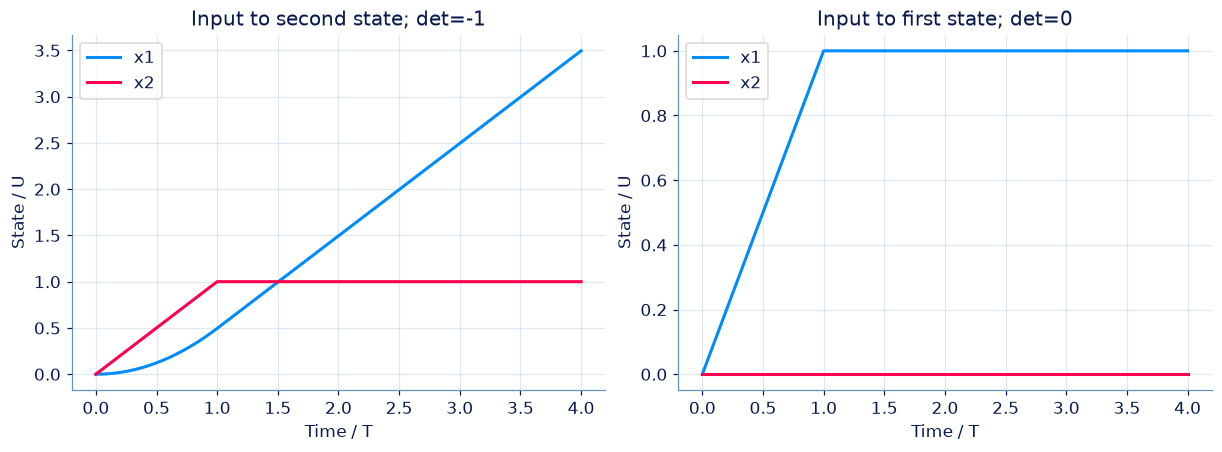

In [4]:
A=[[0.,1.],[0.,0.]];fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,B,label in zip(axes,[[0.,1.],[1.,0.]],['Input to second state','Input to first state']):
    C,det=controllability_2d(A,B);x=np.zeros(2);history=[x.copy()];h=.01
    for n in range(400):
        u=1. if n<100 else 0.
        x=x+h*(np.array(A)@x+np.array(B)*u);history.append(x.copy())
    history=np.array(history);ax.plot(np.arange(401)*h,history[:,0],label='x1');ax.plot(np.arange(401)*h,history[:,1],label='x2')
    ax.set(xlabel='Time / T',ylabel='State / U',title=f'{label}; det={det:g}');ax.legend()
    print(label,'[B,AB]=',C,'det=',det)
plt.show()

## 结果解释

输入到第二状态时，第二状态先改变，再通过A影响第一状态；输入只到第一状态时，第二状态在这个A下始终不变。图显示选定脉冲的响应，秩结论则来自矩阵结构，不能用单条轨迹（trajectory）代替所有输入的证明。

### 独立核对

独立以NumPy矩阵秩检查两种配置，随后改变状态数值单位并观察原始行列式大小如何变化而精确秩不变。

In [5]:
for B,rank in [([0.,1.],2),([1.,0.],1)]:
    C,det=controllability_2d(A,B)
    assert np.linalg.matrix_rank(np.array(C))==rank
scaled=np.diag([1.,1000.]);Bb=scaled@np.array([0.,1.]);Ab=scaled@np.array(A)@np.linalg.inv(scaled)
assert np.linalg.matrix_rank(np.column_stack([Bb,Ab@Bb]))==2
print('独立秩检查和可逆单位缩放保持能控性。')

独立秩检查和可逆单位缩放保持能控性。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：二维能控矩阵

二维线性系统可以是连续模型（model） x′=Ax+Bu，也可以是离散模型 x_next=Ax+Bu；连续模型的 A 描述变化率，离散模型的 A 描述一步更新。两者都计算代数矩阵（matrix） [B,AB] 及行列式（determinant）；题目输入（input）数值尺度固定，满秩（rank）以 |det|>1e−10 判定。

**函数与代码模板**

```python
def solve(
    A: list[list[float]],
    B: list[float],
) -> tuple[list[list[float]], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A` | `list[list[float]]` | 2×2 状态（state）矩阵（matrix）。 | 按状态与时间定义 |
| `B` | `list[float]` | 长度2的单输入列向量（vector）。 | 按状态/输入定义 |

**返回值**

按以下顺序返回元组：(matrix, determinant)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 按行返回 [B,AB]。 | 按输入定义 |
| `determinant` | `float` | 能控矩阵行列式。 | 组合单位 |

**计算规则**

AB_i=Σ_j A_ij B_j，矩阵第1列B、第2列AB；行列式为 ad−bc。

**约束与边界**

- 输入均为有限数；只需实现题定模型，不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A | 2×2 状态（state）矩阵（matrix）。 | [[0.0, 1.0], [0.0, 0.0]] | 按状态与时间定义 |
| B | 长度2的单输入列向量（vector）。 | [0.0, 1.0] | 按状态/输入定义 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A = [[0.0, 1.0], [0.0, 0.0]]
B = [0.0, 1.0]

result = solve(A, B)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | 按行返回 [B,AB]。 | [[0.0, 1.0], [1.0, 0.0]] | 按输入定义 |
| determinant | 能控矩阵行列式。 | -1 | 组合单位 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.0, 1.0], [1.0, 0.0]], -1.0)
```

**样例解释**

双积分模型 B=[0,1] 给出行列式−1；B=[1,0] 则行列式0，第二状态无法受输入影响。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：二维能控矩阵](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/practice/?question=p10-controllability-two)

### 第 2 题 · 单项选择题：同一 A、不同输入位置

A=[[0,1],[0,0]]，B₁=[0,1]ᵀ，B₂=[1,0]ᵀ。哪项正确？

- **A.** [B₁,AB₁] 满秩（rank），而 [B₂,AB₂] 不满秩。
- **B.** 两者都满秩，因为A相同。
- **C.** B₂可直接改变第二状态（state）。
- **D.** 图中的箭头方向无需对应矩阵（matrix）的行列。

[作答：同一 A、不同输入位置](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/practice/?question=p10-actuator-position)

### 第 3 题 · 单项选择题：数值秩不是绝对标签

把状态（state）第二分量的数值单位改为原来的1000倍，直接使用同一个行列式（determinant）阈值。最合理的处理是什么？

- **A.** 报告尺度和容差，并考虑奇异值（singular value）或适当缩放。
- **B.** 行列式非零的数学秩（rank）会随单位变化。
- **C.** 把所有小于1的数值都宣布不可控。
- **D.** 任何双精度计算都能无条件判定精确秩。

[作答：数值秩不是绝对标签](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/practice/?question=p10-rank-tolerance)

### 第 4 题 · 单项选择题：可控就一定可行吗

线性对 (A,B) 可控，但输入（input）存在 |u|≤1 的硬约束。哪项判断正确？

- **A.** 可控性不保证在任意有限时间、任意初态下满足上限地到达目标。
- **B.** 可控性自动提供最小能量解。
- **C.** 可控性说明传感器一定可观。
- **D.** 约束不会影响可达集合。

[作答：可控就一定可行吗](http://127.0.0.1:8000/chapters/10-03-%E8%83%BD%E6%8E%A7%E6%80%A7%E4%B8%8E%E7%8A%B6%E6%80%81%E5%8F%8D%E9%A6%88/practice/?question=p10-controllable-not-feasible)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。